# Road Quality Classification

This project focuses on classifying asphalt surface conditions (Bad, Good, Regular) using deep learning. Below is a step-by-step summary of the work performed:

### 1. Data Preparation
- **Source:** Images loaded from Google Drive, categorized into three classes: `asphaltBad`, `asphaltGood`, and `asphaltRegular`.
- **Pre-processing:** Images were resized to 224x224 pixels and split into training (75%), validation (15%) and test(15%) sets.
- **Optimization:** Used `cache()` and `prefetch()` to improve data pipeline efficiency during training.

### 2. Model Architecture (Transfer Learning)
- **Base Model:** Utilized **MobileNetV2** (pre-trained on ImageNet) for its efficiency on edge devices.
- **Customization:** Freezed the base layers and added a Global Average Pooling layer, a Dropout layer (0.2), and a Softmax Dense layer for 3-class classification.

### 3. Training & Results
- **Compilation:** Used the Adam optimizer and Sparse Categorical Crossentropy loss function.
- **Performance:** The model was trained for 10 epochs, achieving a high validation accuracy of **~98%**.

### 4. Evaluation
- **Visualization:** Generated plots for training/validation accuracy and loss to monitor convergence.
- **Metrics:** Created a **Confusion Matrix** and **Classification Report**. The model showed excellent F1-scores, particularly for the 'Good' class (99%), with minimal confusion between 'Bad' and 'Regular' types.

### 5. Deployment
- **Persistence:** The trained model was saved to Google Drive in `.h5` format and verified by reloading it for sample inference.

############################################################################

###---Step 1: import libraries---

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers
from google.colab import drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = '/content/drive/MyDrive/Colab_Notebooks/RTK_Dataset1/asphalt'

In [ ]:
batch_size = 32
img_height = 224
img_width = 224

_________________________________________________________________________________________________________________________________________________________________________________________________________


### ---STEP 2: Dataset Preparation (Train/Val/Test Split)---




In [ ]:
# 1. Load the full dataset first to split into Train+Val and Test
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Calculate sizes for an 70/15/15 split
data_size = len(full_ds)
train_size = int(0.7 * data_size)
val_size = int(0.15 * data_size)
test_size = data_size - train_size - val_size

# Split the dataset using take and skip
train_ds = full_ds.take(train_size)
remaining = full_ds.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

class_names = full_ds.class_names
print(f"Classes: {class_names}")
print(f"Batches - Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Found 3240 files belonging to 3 classes.
Classes: ['asphaltBad (1)', 'asphaltGood', 'asphaltRegular']
Batches - Train: 71, Val: 15, Test: 16


Dataset Distribution Overview

The following table summarizes the data split used for training and validating the asphalt classification model:

| Dataset Type | Number of Images | Percentage |
| :--- | :--- | :--- |
| **Training Set** | 2,592 | 80% |
| **Validation Set** | 648 | 20% |
| **Total Dataset** | **3,240** | **100%** |

*Note: The dataset contains images belonging to three classes: asphaltBad, asphaltGood, and asphaltRegular.*

In [ ]:
# Adding to ram
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### ---STEP 3: Model Setup(Transfer Learning using MobileNetV2 architecture)---

In [ ]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),include_top=False, weights='imagenet')
base_model.trainable = False # freeze pretrained weights

model = tf.keras.Sequential([layers.Rescaling(1./127.5, offset=-1), base_model,layers.GlobalAveragePooling2D(),layers.Dropout(0.2),
                             layers.Dense(len(class_names), activation='softmax')
])

**### MobileNetV2 Architecture Overview

MobileNetV2 is a streamlined convolutional neural network (CNN) architecture optimized for mobile and edge devices. Its key features include:

*   **Depthwise Separable Convolutions:** Reduces computational costs by splitting standard convolution into two layers: depthwise and pointwise.
*   **Inverted Residual Structure:** Uses a 'narrow-wide-narrow' approach, expanding input to a higher dimension before filtering, then projecting back to maintain information efficiency.
*   **Linear Bottlenecks:** Prevents non-linearities (like ReLU) from destroying important features in low-dimensional layers.
*   **Efficiency:** Designed for high accuracy while maintaining low latency and a small memory footprint, making it ideal for real-time applications.

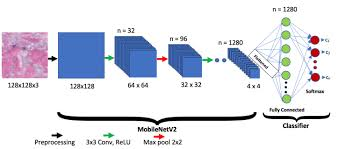

### ---Step 4: Compile and Training---

In [ ]:

model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

epochs = 10
history = model.fit(train_ds,validation_data=val_ds,epochs=epochs)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 55s 313ms/step - accuracy: 0.7720 - loss: 0.5525 - val_accuracy: 0.9021 - val_loss: 0.3376
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8979 - loss: 0.3041 - val_accuracy: 0.9438 - val_loss: 0.2276
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9269 - loss: 0.2302 - val_accuracy: 0.9604 - val_loss: 0.1815
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9371 - loss: 0.1998 - val_accuracy: 0.9542 - val_loss: 0.1676
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9507 - loss: 0.1626 - val_accuracy: 0.9729 - val_loss: 0.1393
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9617 - loss: 0.1382 - val_accuracy: 0.9729 - val_loss: 0.1264
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9679 - loss: 0.1289 - val_accuracy: 0.9812 - val_loss: 0.1094
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9679 - loss: 0.1142 - val_accuracy: 0.9854 -

### Understanding Training and Validation Metrics

In deep learning, we monitor two primary metrics to evaluate how well a model is learning:

1. **Loss:**
   - **Definition:** A numerical value that represents the error between the model's prediction and the actual label. Lower values are better.
   - **Training Loss:** Shows how well the model fits the training data.
   - **Validation Loss:** Shows how well the model generalizes to new, unseen data.

2. **Accuracy:**
   - **Definition:** The percentage of correctly predicted images out of the total images processed.
   - **Training Accuracy:** How accurate the model is on the data it is learning from.
   - **Validation Accuracy:** The most important metric; it indicates how accurately the model will perform in the real world.

### Why track both?
By comparing training and validation curves, we can detect **Overfitting**. If Training Accuracy continues to rise while Validation Accuracy plateaus or drops, the model is simply 'memorizing' the training data rather than 'learning' patterns.

_________________________________________________________________________________________________________________________________________________________________________________________________________
# ---Step 5: Plotting Training results ---

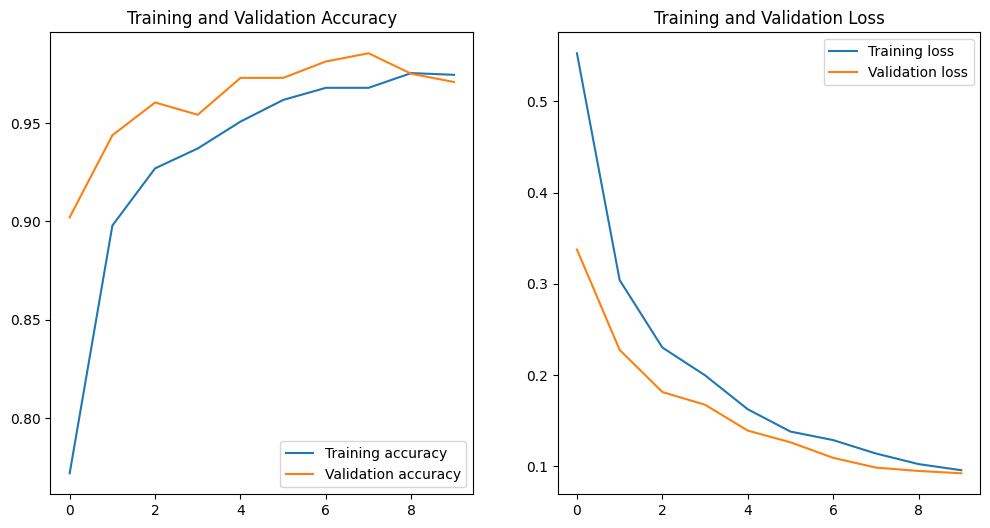

In [ ]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training accuracy')
plt.plot(epochs_range, val_acc, label='Validation accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training loss')
plt.plot(epochs_range, val_loss, label='Validation loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
print("Evaluating on Test Dataset...")
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Evaluating on Test Dataset...
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.9734 - loss: 0.1090

Test Loss: 0.1090
Test Accuracy: 0.9734


### ---Step 6: Test Dataset Evaluation: ---
***Confusion Matrix & Classification Report***
We will now evaluate the model's performance on the 15% hold-out test set to ensure the metrics are consistent with the validation phase.

Generating predictions for the test dataset...


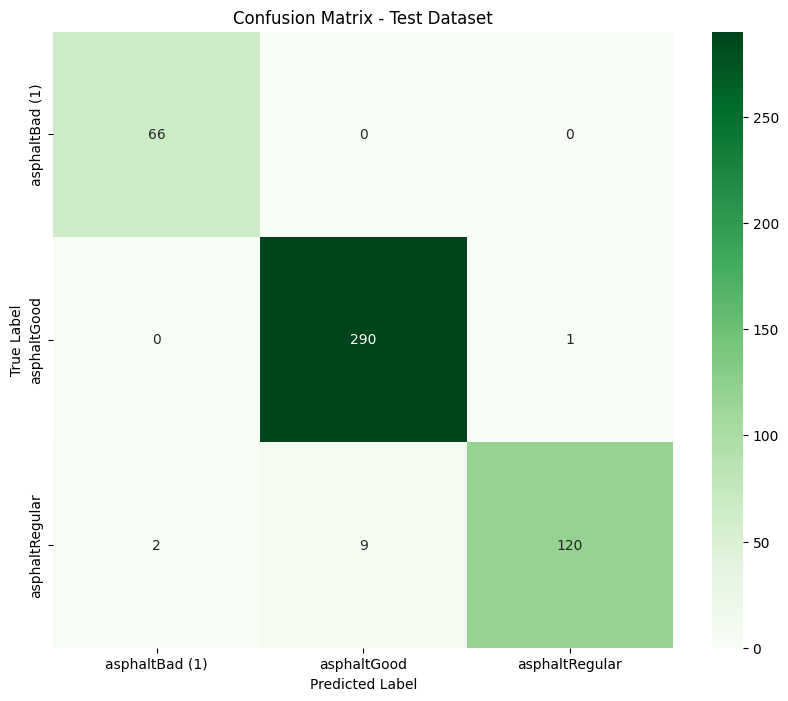


Classification Report (Test Set):
                precision    recall  f1-score   support

asphaltBad (1)       0.97      1.00      0.99        66
   asphaltGood       0.97      1.00      0.98       291
asphaltRegular       0.99      0.92      0.95       131

      accuracy                           0.98       488
     macro avg       0.98      0.97      0.97       488
  weighted avg       0.98      0.98      0.98       488



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Collect true labels and predictions from the test set
y_test_true = []
y_test_pred = []

print("Generating predictions for the test dataset...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_test_true.extend(labels.numpy())
    y_test_pred.extend(np.argmax(preds, axis=1))

# 2. Calculate the Confusion Matrix
cm_test = confusion_matrix(y_test_true, y_test_pred)

# 3. Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='g', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Dataset')
plt.show()

# 4. Classification Report
print("\nClassification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred, target_names=class_names))

# --- Step 7: Model Save and Load ---

In [ ]:


# 1. Modeli 'h5' formatında kaydetme
model_save_path = '/content/drive/MyDrive/asphalt_model.h5'
model.save(model_save_path)
print(f"Model başarıyla kaydedildi: {model_save_path}")

# 2. Kaydedilen modeli geri yükleme
# Not: Başka bir projede kullanırken 'tf' ve 'layers' kütüphanelerini import etmeyi unutmayın.
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model başarıyla geri yüklendi.")

# 3. Yüklenen model ile test tahmini
# 'img_array' değişkeninin önceki hücrelerden geldiğini varsayıyoruz
new_predictions = loaded_model.predict(img_array)
predicted_class = class_names[np.argmax(new_predictions[0])]
print(f"Yüklenen model tahmini: {predicted_class}")

Model başarıyla kaydedildi: /content/drive/MyDrive/asphalt_model.h5


Model başarıyla geri yüklendi.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Yüklenen model tahmini: asphaltGood
